#### Packages

In [1]:
# Python package
import sys
sys.path.append('build')
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
from tqdm import tqdm
from math import *
import random
import matplotlib.pyplot as plt
import os

# Pysat packages
from pysat.card import *
from pysat.pb import PBEnc
from pysat.formula import WCNF, CNF
from pysat.pb import *
from pysat.examples.rc2 import RC2
from pysat.solvers import Glucose4
from pysat.solvers import Solver, Minisat22

#ours package 
import my_tree as mt
import my_tree

# SAT encoding of "Arenas et al 2022" packages
import utils
import dtree
import gen_dt
import encoder 

# import help function and error function 
#from Approx_Functions import W_f, M_s, D_s, Approx_ascendant, Approx_descent, Dichotomie

from openai import OpenAI
import os
from dotenv import load_dotenv
import json
import yaml

#### LLM api calling

In [668]:
# !pip install -q -U google-generativeai
# !pip install --upgrade google-generativeai

In [2]:
from importlib import reload
import llm_calling
reload(llm_calling)
from llm_calling import LlmCalling

llm = LlmCalling()
# llm.grok_llm("c'est quoi l'interpretabilite dans XAI")

#### Dataset loading

In [3]:
class DatasetManager:
    def __init__(self, dataset_name):
        """
        Initialise le gestionnaire de datasets avec configuration YAML
        
        Args:
            dataset_name (str): le nom du dataset qu'on veut charger ses configurations
        """
        self.config_path = "datasets_config.yaml"
        self.dataset_config = self.load_config(dataset_name)
        
    def load_config(self,dataset_name):
        """Charge la configuration d'un dataset depuis le fichier YAML"""
        try:
            with open(self.config_path, 'r', encoding='utf-8') as f:
                return yaml.safe_load(f).get(dataset_name)
        except FileNotFoundError:
            print(f"Fichier de configuration {self.config_path} non trouvé")
            return {"datasets": {}}
        except yaml.YAMLError as e:
            print(f"Erreur de format YAML dans {self.config_path}: {e}")
            return {"datasets": {}}

In [1847]:
dataset_config = DatasetManager("vote_house_84").dataset_config
print(dataset_config)

{'nom': 'vote_house_84', 'chemin_csv': 'datasets/vote_house_84.csv', 'objectif_classification': "Il s'agit d'un modèle de classification binaire destiné à prédire la classe du votant (Democrate: 1, Republicain: 0) en fonctions de leur votes aux differentes types de votes.\n", 'colonne_cible': 'class_name', 'tests_result': {'exemple': {'explication': 'La prédiction du modèle pour cet individu est la classe 0, ce qui signifie qu\'il est classé comme Républicain. Les caractéristiques les plus influentes dans cette décision sont les suivantes :\n\n1. La caractéristique "superfund-right-to-sue" a une valeur de 1, ce qui contribue positivement à la prédiction de la classe 0 avec une contribution de 0.117.\n2. La caractéristique "anti-satellite-test-ban" a une valeur de 0, ce qui contribue négativement à la prédiction de la classe 0 avec une contribution de -0.101.\n3. La caractéristique "immigration" a une valeur de 0, ce qui contribue négativement à la prédiction de la classe 0 avec une con

In [1848]:
#Load data
data = pd.read_csv(dataset_config.get("chemin_csv"))
df = data.copy()

Data exploration

In [1849]:
df.head()

,Class Name,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,0,1,0,1,1,1,0,0,0,0,0,1,1,1,0,0,0
1,1,1,1,1,1,1,0,0,0,0,1,0,1,1,0,0,1
2,0,1,1,0,1,1,0,0,0,0,1,0,1,0,0,1,1
3,1,1,1,0,1,1,0,0,0,0,1,1,1,1,1,1,1
4,0,1,1,0,1,1,0,0,0,0,0,0,1,1,1,1,1


In [1850]:
#dimension du dataset true data
df.shape

(434, 17)

In [1851]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434 entries, 0 to 433
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Class Name                              434 non-null    int64
 1   handicapped-infants                     434 non-null    int64
 2   water-project-cost-sharing              434 non-null    int64
 3   adoption-of-the-budget-resolution       434 non-null    int64
 4   physician-fee-freeze                    434 non-null    int64
 5   el-salvador-aid                         434 non-null    int64
 6   religious-groups-in-schools             434 non-null    int64
 7   anti-satellite-test-ban                 434 non-null    int64
 8   aid-to-nicaraguan-contras               434 non-null    int64
 9   mx-missile                              434 non-null    int64
 10  immigration                             434 non-null    int64
 11  synfuels-corporatio

In [1852]:
# rename columns
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [1853]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434 entries, 0 to 433
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   class_name                              434 non-null    int64
 1   handicapped-infants                     434 non-null    int64
 2   water-project-cost-sharing              434 non-null    int64
 3   adoption-of-the-budget-resolution       434 non-null    int64
 4   physician-fee-freeze                    434 non-null    int64
 5   el-salvador-aid                         434 non-null    int64
 6   religious-groups-in-schools             434 non-null    int64
 7   anti-satellite-test-ban                 434 non-null    int64
 8   aid-to-nicaraguan-contras               434 non-null    int64
 9   mx-missile                              434 non-null    int64
 10  immigration                             434 non-null    int64
 11  synfuels-corporatio

In [1854]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
class_name,434.0,0.451613,0.498228,0.0,0.0,0.0,1.0,1.0
handicapped-infants,434.0,0.511521,0.500444,0.0,0.0,1.0,1.0,1.0
water-project-cost-sharing,434.0,0.599078,0.490651,0.0,0.0,1.0,1.0,1.0
adoption-of-the-budget-resolution,434.0,0.423963,0.494755,0.0,0.0,0.0,1.0,1.0
physician-fee-freeze,434.0,0.513825,0.500386,0.0,0.0,1.0,1.0,1.0
el-salvador-aid,434.0,0.645161,0.479017,0.0,0.0,1.0,1.0,1.0
religious-groups-in-schools,434.0,0.569124,0.495770,0.0,0.0,1.0,1.0,1.0
anti-satellite-test-ban,434.0,0.566820,0.496087,0.0,0.0,1.0,1.0,1.0
aid-to-nicaraguan-contras,434.0,0.520737,0.500146,0.0,0.0,1.0,1.0,1.0
mx-missile,434.0,0.504608,0.500556,0.0,0.0,1.0,1.0,1.0


In [1855]:
#duplicated data number
df.duplicated().sum()

143

data set label distribution:
 class_name
0    238
1    196
Name: count, dtype: int64


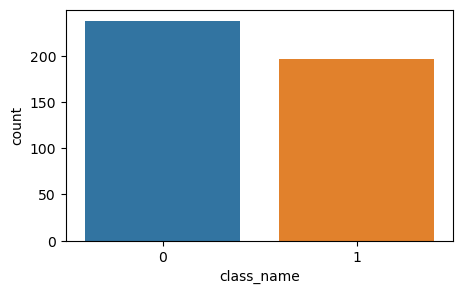

In [1856]:
print('data set label distribution:\n',df[dataset_config.get("colonne_cible")].value_counts())

plt.figure(figsize=(5,3))
sns.countplot(x = df[dataset_config.get("colonne_cible")])
plt.show()

Oversample de la classe minoritaire

In [1857]:
# Détection automatique des classes
def detect_classes_automatically(df, target_column):
    # Compter les occurrences de chaque classe
    class_counts = df[target_column].value_counts()
    
    # Identifier la classe majoritaire et minoritaire
    majority_class = class_counts.idxmax()
    minority_class = class_counts.idxmin()
    
    # Afficher les informations
    print(f"Classe majoritaire: {majority_class} (n={class_counts[majority_class]})")
    print(f"Classe minoritaire: {minority_class} (n={class_counts[minority_class]})")
    print(f"Ratio: {class_counts[majority_class]/class_counts[minority_class]:.2f}:1")
    
    return majority_class, minority_class, class_counts

majority_class, minority_class, counts = detect_classes_automatically(df, dataset_config.get("colonne_cible"))

# Séparation automatique
df_majority = df[df[dataset_config.get("colonne_cible")] == majority_class]
df_minority = df[df[dataset_config.get("colonne_cible")] == minority_class]

Classe majoritaire: 0 (n=238)
Classe minoritaire: 1 (n=196)
Ratio: 1.21:1


In [1858]:
from sklearn.utils import resample
# Oversampling de la classe minoritaire
df_minority_oversampled = resample(df_minority,
                                  replace=True,     # échantillonnage avec remplacement
                                  n_samples=len(df_majority),  # même nombre que la classe majoritaire
                                  random_state=42)

# Combiner les datasets
df = pd.concat([df_majority, df_minority_oversampled])

data set label distribution after oversampling:
 class_name
0    238
1    238
Name: count, dtype: int64


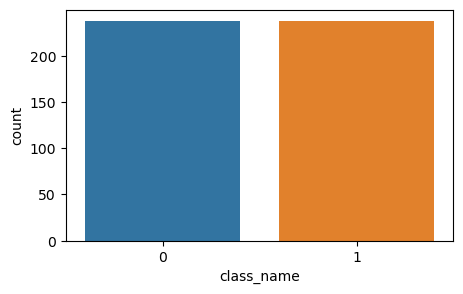

In [1859]:
print('data set label distribution after oversampling:\n',df[dataset_config.get("colonne_cible")].value_counts())

plt.figure(figsize=(5,3))
sns.countplot(x = df[dataset_config.get("colonne_cible")])
plt.show()

DecisionTree model training

In [1860]:
from sklearn.model_selection import GridSearchCV

random_state=42
ind =dataset_config.get("colonne_cible")

y = df[ind]

X = df.drop(ind, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

dt_model = DecisionTreeClassifier(random_state=random_state)

param_grid = {
        'criterion': ['gini', 'entropy'],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 5, 10],
        'max_features': ['sqrt', 'log2', None],
        'class_weight': [None, 'balanced']
    }

grid_search = GridSearchCV(
        estimator=dt_model,
        param_grid=param_grid,
        scoring='accuracy',  # ou 'f1', 'recall', etc. selon votre objectif
        cv=5,               # 5-fold cross-validation
        n_jobs=-1,          # utiliser tous les processeurs
        verbose=1,
        return_train_score=True
    )


In [1861]:
# Exécution de GridSearch
grid_search.fit(X_train, y_train)

# Meilleurs paramètres
print("\nMeilleurs paramètres trouvés:")
print(grid_search.best_params_)
print(f"\nMeilleur score (validation): {grid_search.best_score_:.4f}")

# Évaluation sur le test set
dt = grid_search.best_estimator_
y_pred = dt.predict(X_test)

print("\nRapport de classification:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 1344 candidates, totalling 6720 fits

Meilleurs paramètres trouvés:
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}

Meilleur score (validation): 0.7389

Rapport de classification:
              precision    recall  f1-score   support

           0       0.76      0.64      0.69        64
           1       0.74      0.84      0.79        79

    accuracy                           0.75       143
   macro avg       0.75      0.74      0.74       143
weighted avg       0.75      0.75      0.75       143



invalid value encountered in cast


In [1862]:
my_tree = mt.decision_tree()

my_tree.from_DecisionTreeClassifier(dt)

#### Model Architecture

In [1863]:
i = 1 # the index of instance
file = 'data_dt' # if you want to change the name, you need to change it also in Dichotomie function

dim = df.shape[1] - 1
ind = X_test.index[i]
pred = dt.predict(X_test)[i]
ins = list(X_test.loc[ind]) + [pred]
instance = X_test.loc[ind]

target = my_tree.take_decision(instance=instance)


dnf = my_tree.to_DNF(target=target, threshold_clauses=False)[0].clauses # DNF formula equivalent to tree T

cnf = my_tree.to_CNF(target=target, threshold_clauses=False)[0].clauses # formula CNF equivalet to the tree T

phi = my_tree.to_DNF(target=1-target, threshold_clauses=False)[0].clauses

implicant = my_tree.binarized_instance(instance=instance) # instance binaire


n = len(my_tree.bina)

R_d = my_tree.find_direct_reason(instance=instance) # direct reason 
suffisant_reason = my_tree.find_sufficient_reason(instance=instance)

R = my_tree.unbinarized_instance(R_d)

gen_dt.dt_to_file(dimension = dim, dt=dt, filename=file, desired_n_leaves=80, positive_class=pred) 

n_actual_leaves = 53, desired_n_leaves = 80


Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [1864]:
features = list(set(df.columns) - {dataset_config.get("colonne_cible")})
features

['physician-fee-freeze',
 'handicapped-infants',
 'immigration',
 'anti-satellite-test-ban',
 'aid-to-nicaraguan-contras',
 'crime',
 'duty-free-exports',
 'export-administration-act-south-africa',
 'adoption-of-the-budget-resolution',
 'el-salvador-aid',
 'mx-missile',
 'superfund-right-to-sue',
 'religious-groups-in-schools',
 'education-spending',
 'water-project-cost-sharing',
 'synfuels-corporation-cutback']

In [1865]:
my_tree.bina

{(7, 0.5): [1, 1],
 (3, 0.5): [2, 4],
 (8, 0.5): [3, 4],
 (15, 0.5): [4, 4],
 (14, 0.5): [5, 4],
 (11, 0.5): [6, 4],
 (2, 0.5): [7, 3],
 (6, 0.5): [8, 3],
 (9, 0.5): [9, 4],
 (1, 0.5): [10, 4],
 (10, 0.5): [11, 4],
 (16, 0.5): [12, 2],
 (4, 0.5): [13, 3],
 (12, 0.5): [14, 5],
 (13, 0.5): [15, 3]}

In [1052]:
print(implicant)

[1, 2, 3, 4, 5, 6, 7, -8, 9, -10, 11, 12, 13, -14, -15, -16, -17, 18, -19, -20, 21, 22, -23, 24, -25, -26, -27, 28, 29, -30, -31, -32, -33, 34, -35, 36, 37, -38, -39, -40, -41, -42, 43, 44, 45, -46, 47, 48, 49, 50, 51, 52, -53, 54, 55, -56, -57, -58, -59, -60, 61, -62, -63, -64, -65, -66, -67, -68, 69, -70, -71]


In [130]:
cnf

[[4, 3, -2, 1],
 [5, -4, 3, -2, 1],
 [6, -1],
 [11, 10, 9, -8, 7, -6, -1],
 [-10, 9, -8, 7, -6, -1],
 [13, -12, -7, -6, -1]]

In [620]:
dnf

[[4, 3, -2, -1],
 [-6, -5, 2, -1],
 [-10, 9, -8, -7, 5, 2, -1],
 [7, 5, 2, -1],
 [16, -15, -14, -13, 12, -11, 1],
 [-19, 18, -17, 15, -14, -13, 12, -11, 1],
 [-22, 21, -20, 19, 18, -17, 15, -14, -13, 12, -11, 1],
 [-23, 22, 21, -20, 19, 18, -17, 15, -14, -13, 12, -11, 1],
 [17, 15, -14, -13, 12, -11, 1],
 [25, -24, 14, -13, 12, -11, 1],
 [24, 14, -13, 12, -11, 1],
 [27, -26, 13, 12, -11, 1],
 [26, 13, 12, -11, 1],
 [-31, -30, -10, 29, 28, 11, 1],
 [30, -10, 29, 28, 11, 1],
 [22, 10, 29, 28, 11, 1]]

In [100]:
my_tree.convert_binary_cnf_to_feature_names(cnf,features)

[['degree_percentage  >  70.65499877929688',
  'employability_test_percentage  <  52.239999771118164',
  'salary  >  270000.0',
  'salary  <  262500.0',
  'secondary_education_percentage  >  62.5'],
 ['specialization_in_higher_secondary_education  >  1.5',
  'degree_percentage  <  70.65499877929688',
  'employability_test_percentage  <  52.239999771118164',
  'salary  >  270000.0',
  'salary  <  262500.0',
  'secondary_education_percentage  >  62.5'],
 ['mba_percentage  <  58.46500015258789',
  'salary  <  264500.0',
  'salary  >  267500.0',
  'secondary_education_percentage  <  62.5']]

In [101]:
# restriction of the cnf in a term
restrict_cnf = my_tree.restrict_cnf_to_instance(cnf, implicant)
my_tree.convert_binary_cnf_to_feature_names(restrict_cnf,features)

[['salary  <  262500.0', 'secondary_education_percentage  >  62.5'],
 ['specialization_in_higher_secondary_education  >  1.5',
  'degree_percentage  <  70.65499877929688',
  'salary  <  262500.0',
  'secondary_education_percentage  >  62.5'],
 ['salary  <  264500.0']]

In [102]:
#Convert a binary term to a feature term format
my_tree.convert_binary_term_to_feature_names(implicant,features)

['secondary_education_percentage  >  62.5',
 'salary  <  262500.0',
 'salary  <  270000.0',
 'employability_test_percentage  >  52.239999771118164',
 'degree_percentage  <  70.65499877929688',
 'specialization_in_higher_secondary_education  >  1.5',
 'salary  <  267500.0',
 'salary  <  264500.0',
 'mba_percentage  >  58.46500015258789']

In [38]:
raison_suffisante = my_tree.convert_binary_term_to_feature_names(suffisant_reason,features)
raison_suffisante

['other  <  0.5',
 'hispanic  <  0.5',
 'native_american  <  0.5',
 'african_american  <  0.5',
 'misdemeanor  >  0.5',
 'number_of_priors  <  2.5',
 'number_of_priors  <  1.5']

### Generation d'explication avec LLM

In [2466]:
features = df.columns.drop(dataset_config.get("colonne_cible"))
instance = X_test.iloc[15]
prediction = dt.predict_proba(instance.values.reshape(1, -1))[0]
classe_predite = prediction.argmax()
probabilite_predite = prediction[0]
instance_dict = dict(instance)

target = my_tree.take_decision(instance=instance)

implicant = my_tree.binarized_instance(instance=instance)
cnf = my_tree.to_CNF(target=target, threshold_clauses=False)[0].clauses
dnf = my_tree.to_DNF(target=target, threshold_clauses=False)[0].clauses
phi = my_tree.to_DNF(target=1-target, threshold_clauses=False)[0].clauses

restrict_cnf = my_tree.restrict_cnf_to_instance(cnf, implicant)
instance_cnf = my_tree.convert_binary_cnf_to_feature_names(restrict_cnf,features)
instance_dnf = my_tree.convert_binary_cnf_to_feature_names(dnf,features)
print(target)
print(instance_cnf)

1
[['duty-free-exports  >  0.5', 'aid-to-nicaraguan-contras  >  0.5', 'anti-satellite-test-ban  >  0.5'], ['synfuels-corporation-cutback  <  0.5', 'crime  >  0.5', 'aid-to-nicaraguan-contras  >  0.5', 'anti-satellite-test-ban  >  0.5'], ['religious-groups-in-schools  >  0.5', 'aid-to-nicaraguan-contras  >  0.5', 'anti-satellite-test-ban  >  0.5'], ['aid-to-nicaraguan-contras  >  0.5', 'anti-satellite-test-ban  >  0.5'], ['synfuels-corporation-cutback  <  0.5', 'anti-satellite-test-ban  >  0.5'], ['mx-missile  >  0.5', 'duty-free-exports  >  0.5', 'adoption-of-the-budget-resolution  <  0.5', 'anti-satellite-test-ban  >  0.5'], ['synfuels-corporation-cutback  <  0.5', 'duty-free-exports  >  0.5', 'adoption-of-the-budget-resolution  <  0.5', 'anti-satellite-test-ban  >  0.5'], ['immigration  <  0.5', 'synfuels-corporation-cutback  <  0.5', 'duty-free-exports  >  0.5', 'adoption-of-the-budget-resolution  <  0.5', 'anti-satellite-test-ban  >  0.5'], ['export-administration-act-south-africa 

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [2467]:
instance_dnf

[['synfuels-corporation-cutback  <  0.5',
  'crime  <  0.5',
  'duty-free-exports  >  0.5',
  'aid-to-nicaraguan-contras  <  0.5',
  'adoption-of-the-budget-resolution  <  0.5',
  'anti-satellite-test-ban  <  0.5'],
 ['water-project-cost-sharing  <  0.5',
  'synfuels-corporation-cutback  >  0.5',
  'crime  <  0.5',
  'duty-free-exports  >  0.5',
  'aid-to-nicaraguan-contras  <  0.5',
  'adoption-of-the-budget-resolution  <  0.5',
  'anti-satellite-test-ban  <  0.5'],
 ['synfuels-corporation-cutback  >  0.5',
  'religious-groups-in-schools  <  0.5',
  'crime  >  0.5',
  'duty-free-exports  >  0.5',
  'aid-to-nicaraguan-contras  <  0.5',
  'adoption-of-the-budget-resolution  <  0.5',
  'anti-satellite-test-ban  <  0.5'],
 ['duty-free-exports  <  0.5',
  'synfuels-corporation-cutback  <  0.5',
  'aid-to-nicaraguan-contras  >  0.5',
  'adoption-of-the-budget-resolution  <  0.5',
  'anti-satellite-test-ban  <  0.5'],
 ['religious-groups-in-schools  <  0.5',
  'duty-free-exports  >  0.5',
  

In [2468]:
prompt_template = """
System:
Tu es un expert en machine learning chargé d'expliquer la decision du modèle à produire une prédiction spécifique. 

Role:
Agis en tant qu’expert en apprentissage automatique et fournis des explications précises et accessibles, en te basant uniquement sur les informations fournies dans le contexte.

Contexte :
- Objectifs du Modèle: {model_objectif}
- Valeurs des caractéristiques de l'individu analysé : {instance_dict}
- Classe prédite pour cette instance : Classe {classe_predite}
{local_interpretaion}
Consignes:
  - L’explication doit être concise, claire.
  - Concentre-toi uniquement les features les plus influents dans la décision avec leur valeur qu'il prennent.
  - N'utilisez aucun caractère spécial pour la mise en forme de la sortie.

Question de l’utilisateur :
{user_query}

"""

In [1869]:
user_query = """Explique moi les raisons de cette prediction du modele"""

##### Sans contexte XAI classiques

In [160]:
simple_prompt =  prompt_template.format(
    instance_dict = instance_dict,
    classe_predite = classe_predite,
    local_interpretaion = "",
    user_query = user_query,
    model_objectif = dataset_config.get("objectif_classification")
)

In [161]:
print(llm.OpenAI_llm(simple_prompt))

Le modèle a prédit la survie (classe 1) pour cette patiente après une opération du cancer du sein. Les caractéristiques influentes dans cette décision sont les suivantes :

1. Age : La patiente a 53 ans. Un âge relativement jeune peut être associé à un meilleur pronostic de survie après une opération du cancer du sein.

2. Nombre de ganglions axillaires : La patiente a 12 ganglions axillaires. Bien que ce nombre soit relativement élevé, d'autres facteurs comme l'âge peuvent avoir compensé cet effet négatif potentiel.

Ces caractéristiques ont probablement joué un rôle clé dans la prédiction de survie par le modèle.


In [162]:
print(llm.claud_llm(simple_prompt))

Le modèle a prédit la survie (Classe 1) pour cette patiente de 53 ans. Voici l'analyse des facteurs clés qui ont influencé cette décision :

**Facteur le plus critique :**
- **Nombre de ganglions axillaires atteints : 12** - C'est probablement le facteur le plus déterminant mais défavorable. Un nombre élevé de ganglions lymphatiques cancéreux (12) indique généralement une propagation importante du cancer et constitue normalement un facteur de mauvais pronostic.

**Facteurs favorables :**
- **Age : 53 ans** - Cet âge relativement jeune joue en faveur de la survie, car les patientes plus jeunes ont généralement de meilleures capacités de récupération et répondent mieux aux traitements.

- **Année d'opération : 1965** - Bien que les techniques médicales de 1965 soient moins avancées qu'aujourd'hui, le modèle semble avoir identifié des patterns spécifiques dans les données historiques de cette période.

**Conclusion :**
Malgré le nombre élevé de ganglions atteints qui est préoccupant, l'âg

#### Utilisant SHAP comme contexte

In [1149]:
import shap
import matplotlib.pyplot as plt

# load JS visualization code to notebook
shap.initjs()

# Create the explainer
explainer = shap.TreeExplainer(dt)

shap_values = explainer.shap_values(X_test)

Formatage  des valeurs SHAP: 
Formatage sous forme d'un dictionnaire où les clés sont les noms des features et les valeurs sont les contributions SHAP moyennes exprimees en pourcentage.

In [1150]:
# Calculer la moyenne absolue des valeurs SHAP pour chaque feature
def shapley_values(classe=target):
    mean_shap_values = np.abs(shap_values[classe]).mean(axis=0)

    total_shap = mean_shap_values.sum()
    shap_percentages = (mean_shap_values / total_shap) * 100
    # Créer le dictionnaire {feature: valeur SHAP moyenne}
    shap_dict = dict(zip(X_test.columns, shap_percentages))

    # Afficher le dictionnaire
    return shap_dict

shapley_values()

{'gender': 0.0,
 'secondary_education_percentage': 31.290129915890347,
 'board_of_education': 0.0,
 'higher_secondary_education_percentage': 13.285069608478455,
 'board_of_education.1': 0.0,
 'specialization_in_higher_secondary_education': 0.0,
 'degree_percentage': 18.984001305648633,
 'degree_education': 0.0,
 'work_experience': 0.0,
 'employability_test_percentage': 4.068447139921407,
 'post_graduation_specialization': 0.0,
 'mba_percentage': 1.4108932437817763,
 'salary': 30.96145878627939}

In [59]:
shap_dict = shapley_values(classe=classe_predite)

shap_local_interpretation = f"""- Interprétation locale de la prédiction (méthode SHAP) :
    - shap est méthode vise à expliquer la prédiction d'une instance/observation en calculant la contribution de chaque caractéristique à la prédiction. 
    - Les valeus de shape sont des pourcentages de contribution de chaque variable sur le prediction de l'instance
    - Valeurs de shape: {shap_dict}
"""

In [61]:
shap_prompt = prompt_template.format(
    instance_dict = instance_dict,
    classe_predite = classe_predite,
    local_interpretaion = shap_local_interpretation,
    user_query = user_query,
    model_objectif = dataset_config.get("objectif_classification")
)

In [62]:
# Geneartion d'explication en fournisant un prompt qui a comme contexte:
# - les valeurs de SHAP 
# llm utilisee : openAi(gpt-4o)
print(llm.OpenAI_llm(shap_prompt))

La prédiction du modèle pour cet individu est la classe 0, ce qui signifie que le modèle a prédit que l'individu n'est pas coupable. Les caractéristiques les plus influentes dans cette décision sont "Number_of_Priors" et "score_factor", qui ont respectivement contribué à hauteur de 27.84% et 26.56% à la prédiction. Ces deux caractéristiques ont probablement eu un impact significatif en faveur de la classe 0. De plus, les caractéristiques "Age_Below_TwentyFive" et "Female" ont également eu une influence notable, avec des contributions de 13.38% et 7.37% respectivement. Ces contributions indiquent que le fait d'avoir peu de condamnations antérieures, un score factor favorable, et d'être une femme jeune a joué un rôle important dans la prédiction de non-culpabilité par le modèle.


In [139]:
# Generation d'explication fournisant comme contexte les valeurs de SHAP
# le llm utilisee: claud(claude-opus-4-20250514)
print(llm.claud_llm(shap_prompt))

Le modèle a prédit que cet individu n'est pas coupable (classe 0). Cette décision s'appuie principalement sur trois caractéristiques clés qui ont le plus influencé la prédiction :

1. Number_of_Priors (28,75% de contribution) : L'individu a 2 antécédents judiciaires. Ce nombre relativement faible a fortement contribué à la prédiction de non-culpabilité.

2. score_factor (26,56% de contribution) : Avec une valeur de 0, ce score indique un risque très faible, ce qui a significativement orienté le modèle vers une prédiction de non-culpabilité.

3. Age_Below_TwentyFive (13,15% de contribution) : Le fait que l'individu ne soit pas âgé de moins de 25 ans (valeur = 0) a également joué un rôle important dans cette prédiction, suggérant que l'âge plus mature est associé à un risque moindre.

Ces trois variables représentent ensemble plus de 68% de la décision du modèle. Les autres caractéristiques, bien que présentes, ont eu une influence beaucoup plus limitée sur la prédiction finale. Le modèl

In [32]:
# Generation d'explication fournisant comme contexte les valeurs de SHAP
# le llm utilisee: llama
print(llm.llama_llm(shap_prompt))

Le modèle utilisé est un arbre de décision entraîné pour prédire si un individu est coupable (classe 1) ou non (classe 0). Pour cette instance, le modèle a prédit la classe 0.

Selon l'interprétation locale de la prédiction (méthode SHAP), les caractéristiques ayant la plus forte contribution à la prédiction sont :

- 'Number_of_Priors' : 27,84 % : le fait que l'individu ait un seul antécédent pénal est un facteur important pour la prédiction.
- 'score_factor' : 26,56 % : le score de l'individu est également un facteur important, mais il semble que le score ne soit pas très élevé.
- 'Age_Below_TwentyFive' : 13,38 % : l'âge de l'individu, en particulier son jeune âge, est également un facteur important pour la prédiction.
- 'Female' : 7,37 % : le sexe de l'individu, en particulier le fait qu'il s'agit d'une femme, est également un facteur important.
- 'Misdemeanor' : 6,94 % : le fait que l'individu ait un délit de moindre importance est également un facteur important.

Ces caractéristiq

##### Importance des variables et graphique de synthèse

Dans ce graphique, les caractéristiques sont classées en fonction de leur valeur SHAP moyenne, \\\
les plus importantes étant placées en haut et les moins importantes en bas, à l'aide de la fonction summary_plot(). \\\
Cela permet de comprendre l'impact de chaque caractéristique sur les prédictions du modèle.

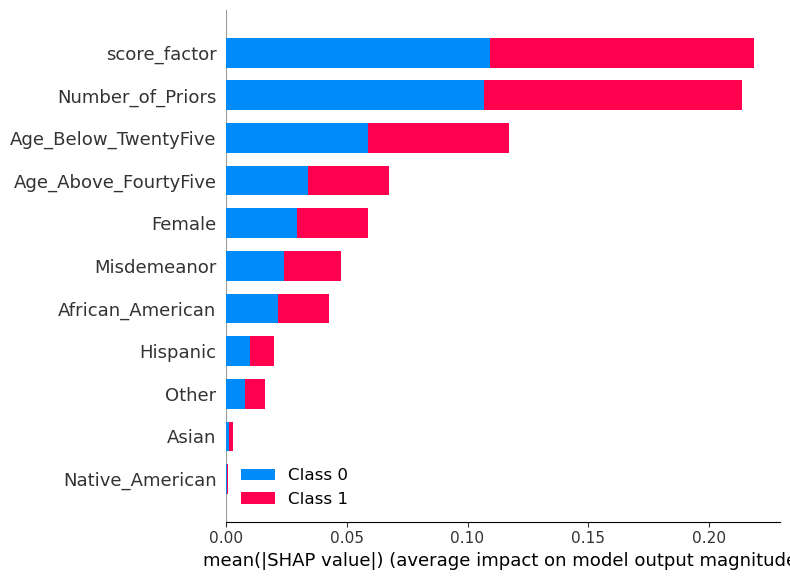

In [28]:
import numpy as np

# Moyenne absolue des SHAP values sur la dimension des classes (axis=2)
#shap_values_mean = np.mean(np.abs(shap_values), axis=2)

shap.summary_plot(shap_values, X_test)



##### Graphique de synthèse sur une étiquette spécifique
Cette approche permet d'obtenir une vue d'ensemble plus granulaire de l'impact de 
chaque caractéristique sur un résultat spécifique (étiquette).

Dans l'exemple ci-dessous, shap_values[:,:,1] est utilisé pour représenter les valeurs SHAP 
des instances classées sous l'étiquette 1.

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


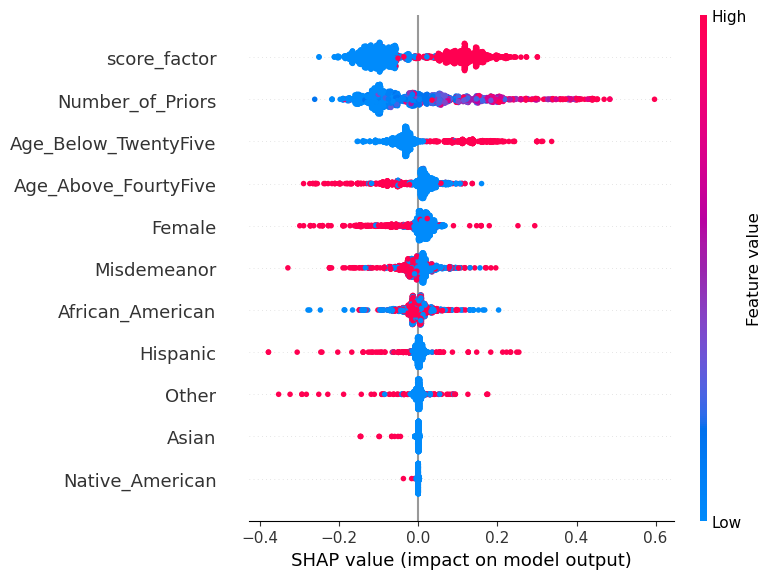

In [29]:
figure = plt.figure()
shap.summary_plot(shap_values[1], X_test)


##### Graphique de dépendance

Contrairement aux diagrammes de synthèse, les diagrammes de dépendance montrent la relation entre une caractéristique spécifique et le résultat prédit pour chaque cas dans les données. \\\
Cette analyse est effectuée pour de multiples raisons et ne se limite pas à l'obtention d'informations plus granulaires et à la validation de l'importance de l'élément analysé \\\
en confirmant ou en remettant en question les résultats des diagrammes de synthèse ou d'autres mesures globales de l'importance de l'élément. 


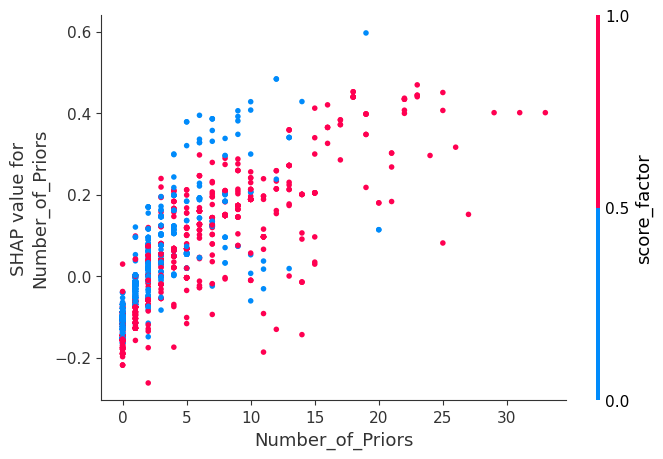

In [30]:
shap.dependence_plot(
    ind='Number_of_Priors',  
    shap_values=shap_values[1],
    features=X_test
)


#### Utilisant LIME comme contexte

In [2469]:
# Import the LimeTabularExplainer module
from lime.lime_tabular import LimeTabularExplainer

# Get the class names
class_names = df[dataset_config.get("colonne_cible")].unique().tolist()

# Get the feature names
feature_names = list(X_train.columns)

# Fit the Explainer on the training data set using the LimeTabularExplainer
explainer = LimeTabularExplainer(X_train.values,
                                 feature_names = feature_names,
                                 class_names = class_names, 
                                 mode = 'classification')

In [2470]:
# Explain the index 5 instance prediction
exp = explainer.explain_instance(
    instance.values, 
    dt.predict_proba
)
lime_data = exp.as_list()
lime_data

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


[('0.00 < anti-satellite-test-ban <= 1.00', 0.2228384285278086),
 ('synfuels-corporation-cutback <= 0.00', 0.14588920689113297),
 ('0.00 < religious-groups-in-schools <= 1.00', -0.08817474578380238),
 ('superfund-right-to-sue <= 0.00', -0.07900810674554054),
 ('0.00 < mx-missile <= 1.00', 0.0714000795072172),
 ('0.00 < water-project-cost-sharing <= 1.00', 0.07064437419964775),
 ('education-spending <= 0.00', 0.06660355746793203),
 ('handicapped-infants <= 0.00', -0.05717579705384714),
 ('adoption-of-the-budget-resolution <= 0.00', 0.03389128419780647),
 ('0.00 < crime <= 1.00', -0.024685527053181874)]

Generation d'explication par LLM guide par LIME

In [2471]:
lime_feature_contribution = f""""""
for feature, weight in lime_data:
    lime_feature_contribution += f"{feature}: Contribution = {weight:.3f} \n"

lime_interpretation = f"""- Interprétation locale de la prédiction (méthode LIME) :
  - LIME se concentre sur l'explication de la prédiction du modèle pour des instances individuelles
  - Valeurs LIME (contribution à la prédiction):
    {lime_feature_contribution}
"""

In [2472]:
lime_prompt = prompt_template.format(
    instance_dict = instance_dict,
    classe_predite = classe_predite,
    local_interpretaion = lime_interpretation,
    user_query = user_query,
    model_objectif = dataset_config.get("objectif_classification")
)

In [309]:
# Generation d'explication en utilisant le llm OpenAI(gpt-4o)
print(llm.OpenAI_llm(lime_prompt))

La prédiction du modèle pour cet individu, classé comme Démocrate (classe 1), est principalement influencée par plusieurs caractéristiques. Les caractéristiques les plus influentes sont les suivantes :

1. La caractéristique "superfund-right-to-sue" avec une valeur de 0 a une contribution négative significative de -0.138 à la prédiction, ce qui signifie qu'elle tend à éloigner la prédiction de la classe Démocrate.

2. La caractéristique "anti-satellite-test-ban" avec une valeur de 1 a une contribution positive de 0.094, ce qui favorise la prédiction vers la classe Démocrate.

3. La caractéristique "water-project-cost-sharing" avec une valeur de 1 contribue positivement avec 0.079 à la prédiction, renforçant l'affiliation Démocrate.

4. La caractéristique "aid-to-nicaraguan-contras" avec une valeur de 1 a une contribution négative de -0.078, ce qui tend à éloigner la prédiction de la classe Démocrate.

5. La caractéristique "el-salvador-aid" avec une valeur de 1 a également une contribu

In [310]:
# Geneartion d'explication en fournisant un prompt qui a comme contexte:
# - les valeurs de LIME
# llm utilisee : CLAUD
print(llm.claud_llm(lime_prompt))

Basé sur l'analyse LIME, le modèle a prédit que cette personne est un votant Démocrate (classe 1) en se basant principalement sur ces votes clés :

**Facteurs favorisant la prédiction Démocrate :**

- **superfund-right-to-sue = 0** : La contribution la plus forte (+0.138) provient du vote contre ce projet de loi environnemental, ce qui est typiquement associé aux Démocrates
- **anti-satellite-test-ban = 1** : Le vote pour l'interdiction des tests anti-satellites (+0.094) reflète une position démocrate sur le désarmement
- **water-project-cost-sharing = 1** : Le soutien au partage des coûts des projets hydrauliques (+0.079) aligne avec les positions démocrates sur l'infrastructure publique
- **adoption-of-the-budget-resolution = 0** : Le vote contre cette résolution budgétaire (+0.061) correspond aux tendances démocrates
- **immigration = 1** : Le vote pro-immigration (+0.061) est cohérent avec les positions démocrates

**Facteurs atténuants :**

Certains votes comme le soutien à l'aide

#### Utilisant Anchors comme contexte
Contrairement a SHAPE et LIME, anchors fournit des conditions suffisantes - si ces conditions se maintiennent,\\\
la prédiction du modèle est presque garantie de rester la même.

In [27]:
#! pip install alibi
from alibi.explainers import AnchorTabular

predict_fn = dt.predict
# Define the explainer
explainer = AnchorTabular(predict_fn,feature_names=X_train.columns.tolist(), categorical_names={})

# Fit the explainer with the dataset
explainer.fit(X_train.values)

# Expliquer un échantillon
idx = 2
explanation = explainer.explain(X_test.values[idx])
print(f"Anchor: {explanation.anchor}")
print(f"Precision: {explanation.precision:.2f}")

2025-10-06 18:07:35.713905: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature 

Anchor: ['joining_year <= 2017.00', 'city <= 0.00', 'age <= 26.00', 'payment_tier > 2.00', 'education <= 0.00', 'ever_benched <= 0.00', 'experience_in_current_domain > 3.00']
Precision: 0.98


X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassif

In [28]:
anchor_context = f"""- Interprétation locale de la prédiction (méthode LIME)
    - Anchors est une méthode d’explication locale, agnostique au modèle. Il génère des règles conditionnelles à l’aide de perturbations contrôlées pour expliquer la prédiction.
    - Résultat :
        - Règle (anchor) identifiée : {explanation.anchor}
        - Précision de l’ancre : {explanation.precision:.2f} (proportion d’exemples similaires où la prédiction reste la même lorsque l’ancre s’applique)
"""

In [29]:
anchor_prompt = prompt_template.format(
    instance_dict = instance_dict,
    classe_predite = classe_predite,
    local_interpretaion = anchor_context,
    user_query = user_query,
    model_objectif = dataset_config.get("objectif_classification")
)

In [31]:
#Generation d'explication avec openAi
print(llm.OpenAI_llm(anchor_prompt))

In [136]:
#Generation d'explication avec claud
print(llm.claud_llm(anchor_prompt))

Le modèle a prédit que cet individu n'est pas coupable (classe 0) en se basant sur trois critères principaux qui, ensemble, mènent à cette décision avec une fiabilité de 97%.

Les facteurs déterminants sont :

1. Un score de facteur de risque nul (score_factor = 0), indiquant l'absence d'indicateurs de risque dans le profil de l'individu.

2. L'âge de la personne qui est supérieur à 45 ans (Age_Above_FourtyFive = 1), ce qui représente un facteur protecteur dans la prédiction du modèle.

3. Un nombre limité d'antécédents judiciaires (Number_of_Priors = 2, qui reste inférieur ou égal à 4), suggérant un historique criminel modéré.

La combinaison de ces trois conditions forme une règle solide pour prédire l'innocence. Lorsque ces trois critères sont réunis, le modèle prédit la non-culpabilité dans 97% des cas similaires. Les autres caractéristiques de l'individu, comme son origine ethnique ou le fait qu'il ne s'agisse pas d'un délit mineur, n'ont pas eu d'impact significatif sur cette déc

#### Methodes formelles

In [73]:
suffisant_reason = my_tree.find_sufficient_reason(instance=instance)
raison_suffisante = my_tree.convert_binary_term_to_feature_names(suffisant_reason,features)
raison_suffisante

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


['Age_Below_TwentyFive  <  0.5',
 'African_American  >  0.5',
 'Hispanic  <  0.5',
 'Female  >  0.5',
 'Number_of_Priors  <  1.5',
 'Number_of_Priors  <  8.5',
 'Number_of_Priors  <  4.5']

In [76]:
local_interpretation = f"""Raison suffisante associée à cette instance : {raison_suffisante}"""

sr_prompt = prompt_template.format(
    instance_dict = instance_dict,
    classe_predite = classe_predite,
    local_interpretaion = local_interpretation ,
    user_query = user_query
)

In [77]:
# Generation d'explication en utilisant le llm OpenAI(gpt-4o)
print(llm.OpenAI_llm(sr_prompt))

Le modèle a prédit que l'individu n'est pas coupable (classe 0) en se basant principalement sur les caractéristiques suivantes :

1. Age_Below_TwentyFive est inférieur à 0.5 : Cela signifie que l'individu a 25 ans ou plus, ce qui peut être associé à un risque plus faible de récidive.
2. African_American est supérieur à 0.5 : L'individu est identifié comme Afro-Américain, mais cette caractéristique seule n'a pas suffi à influencer la prédiction vers la culpabilité.
3. Female est supérieur à 0.5 : L'individu est de sexe féminin, ce qui est souvent corrélé avec un risque plus faible de comportement criminel.
4. Number_of_Priors est inférieur à 1.5 : L'individu a peu ou pas d'antécédents judiciaires, ce qui réduit la probabilité de culpabilité.

Ces caractéristiques combinées ont conduit le modèle à prédire que l'individu n'est pas coupable.


In [151]:
# Geneartion d'explication en fournisant un prompt qui a comme contexte:
# - la raison suffisante
# llm utilisee : CLAUD
print(llm.claud_llm(sr_prompt))

Le modèle a prédit que cet individu n'est pas coupable (classe 0) en se basant sur plusieurs critères clés.

Les facteurs déterminants dans cette décision sont :

1. L'âge de la personne : L'individu a plus de 45 ans (Age_Above_FourtyFive = 1). Le modèle considère que les personnes de moins de 45 ans ont plus de risques d'être coupables, ce qui joue en faveur de cet individu.

2. L'origine ethnique : La personne est afro-américaine (African_American = 1). Cependant, la règle de décision indique que pour prédire la non-culpabilité, il faut que African_American soit inférieur à 0.5, ce qui suggère que d'autres facteurs ont compensé cette caractéristique.

3. Le score de risque : Le score_factor de 0 est très bas. Toutes les conditions mentionnées (score_factor < 8.5, < 4.5, et < 2.5) sont satisfaites, indiquant un très faible niveau de risque selon le modèle.

4. L'absence de délit mineur : La personne n'a pas commis de délit mineur (Misdemeanor = 0), ce qui renforce la prédiction de non

#### Explanation evaluation

In [32]:
def bina_term_transform(term,features):
    """ Conversion de term en representation binaire"""
    bina_tree = my_tree.bina
    def parse_condition(condition):
        if '<=' in condition:
            var, val = condition.split('<=')
            return (features.get_loc(var.strip())+1, 0, float(val.strip()))
        elif '<' in condition:
            var, val = condition.split('<')
            return (features.get_loc(var.strip())+1, 0, float(val.strip()))
        elif '>=' in condition:
            var, val = condition.split('>=')
            return (features.get_loc(var.strip())+1, 1, float(val.strip()))
        elif '>' in condition:
            var, val = condition.split('>')
            return (features.get_loc(var.strip())+1, 1, float(val.strip()))
        elif '=' in condition:
            var, val = condition.split('=')
            return (features.get_loc(var.strip())+1, 1, float(val.strip()))
        else:
            raise ValueError(f"Condition mal formée : {condition}")

    parsed_conditions = [parse_condition(cond) for cond in term]
    print(parsed_conditions)
    result = []
    
    for x, y, z in  parsed_conditions:
        matching_keys = [key for key in bina_tree.keys() if key[0] == x]
        
        if matching_keys:
            for key in matching_keys:
                k, l = key
                t, c = bina_tree[key]
                
                if y == 1 and z == l:
                    result.append(t)
                    break   
                elif y == 0 and z == l:
                    result.append(-t)
                    break
    return result

def W_f(dnf, t, n): # dnf : Orthogonal dnf, t: term, n: number of features  
    w = 0
    def check(C, t_d): # C: term in dnf, t_d: delta probable desired
        for c in t_d:
            if -c in C:
                return 0
        return len(set(C+t_d))
    for cl in dnf:
        if check(cl, t) != 0:
            w += 2**(n-check(cl, t))
    return w/2**(n-len(t))

In [33]:
class LlmUse:
    """
    Classe pour gérer l'utilisation de différents LLMs.
    """

    def __init__(self, llm_name="deepseek"):
        # Dictionnaire qui mappe le nom du LLM à sa fonction
        self.llm_map = {
            "deepseek": llm.deepseek_llm,
            "llama": llm.llama_llm,
            "openai": llm.OpenAI_llm,
            "claude": llm.claud_llm,   # corrigé "claud" -> "claude"
            "gemini":llm.gemini_llm,
            "grok":llm.grok_llm,
        }
        if llm_name not in self.llm_map:
            raise ValueError(f"LLM '{llm_name}' non supporté. "
                             f"Choisissez parmi: {list(self.llm_map.keys())}")
        
        self.llm_name = llm_name

    def inference(self, prompt: str):
        """
        Exécute une inférence avec le LLM choisi.
        """
        llm_function = self.llm_map[self.llm_name]
        return llm_function(prompt)


In [2489]:
llm_use = LlmUse("claude")
explication_texte = llm_use.inference(lime_prompt)
print(explication_texte)

D'après l'analyse LIME, le modèle a prédit que cet individu est un électeur Démocrate (Classe 1) en se basant principalement sur ces votes clés :

**Facteurs favorisant la prédiction Démocrate :**

- **anti-satellite-test-ban = 1** (contribution +0.223) : Le vote pour l'interdiction des tests anti-satellites est le facteur le plus déterminant, poussant fortement vers une classification démocrate.

- **synfuels-corporation-cutback = 0** (contribution +0.146) : Le vote contre les réductions budgétaires des entreprises de carburants synthétiques contribue significativement à la prédiction démocrate.

- **mx-missile = 1** (contribution +0.071) : Le vote pour le programme de missiles MX renforce modérément la prédiction.

- **water-project-cost-sharing = 1** et **education-spending = 0** contribuent également positivement mais dans une moindre mesure.

**Facteurs atténuant la prédiction :**

- **religious-groups-in-schools = 1** (contribution -0.088) : Ce vote va à l'encontre du profil démo

In [2490]:
rules_extraction_prompt = f"""
Tu es un assistant expert en extraction d'informations logiques à partir de textes explicatifs en langage naturel décrivant les décisions prises par un modèle d'apprentissage automatique.

Ton objectif est d’extraire toutes les conditions implicites ou explicites contenues dans l’explication, exprimées sous forme de comparaison logique entre une variable et une valeur.
### Format de sortie :
Une liste de chaînes de caractères au format :
   <nom_variable> <opérateur> <valeur>

---
### Règles de correspondance
- `<var> = 1` ⇔ `<var> > 0.5 et <var> <= 1`
- `<var> = 0` ⇔ `<var> < 0.5`
- `<var> = n` avec n >= 1 ⇔ `<var> > n - 0.5` et `<var> <= n`
- scope de Variables : {list(features)} 

---

### Variables autorisées :
Tu dois uniquement extraire les conditions portant sur les variables suivantes :
{list(features)}

---

### Exemple :
**Explication :**  
{dataset_config.get("tests_result").get("exemple").get("explication")}

**Sortie :**
{dataset_config.get("tests_result").get("exemple").get("regles")}

---
Contraintes :
- La sortie doit etre une liste des regles, pas de texte supplementaire ni de code block (éviter ```json``` ou ```text```).
- Toujours utiliser des comparaisons simples (ex: 'var <= 3', 'age > 25').
- Ne jamais combiner en une seule ligne du type 'val1 < var <= val2'.  
  À la place :  
  - 'var > val1'  
  - 'var <= val2'

### Explication :
{explication_texte}

### sortie

"""

In [2491]:
# print(extraction_prompt)

In [2492]:
rules_extraites = llm_use.inference(rules_extraction_prompt)

In [2493]:
rules_extraites

"['anti-satellite-test-ban > 0.5', 'anti-satellite-test-ban <= 1', 'synfuels-corporation-cutback < 0.5', 'mx-missile > 0.5', 'mx-missile <= 1', 'water-project-cost-sharing > 0.5', 'water-project-cost-sharing <= 1', 'education-spending < 0.5', 'religious-groups-in-schools > 0.5', 'religious-groups-in-schools <= 1', 'superfund-right-to-sue < 0.5']"

In [2494]:
import ast
rules_extraites = ast.literal_eval(rules_extraites)
rules_extraites = list(map(str.lower, rules_extraites))
rules_extraites

['anti-satellite-test-ban > 0.5',
 'anti-satellite-test-ban <= 1',
 'synfuels-corporation-cutback < 0.5',
 'mx-missile > 0.5',
 'mx-missile <= 1',
 'water-project-cost-sharing > 0.5',
 'water-project-cost-sharing <= 1',
 'education-spending < 0.5',
 'religious-groups-in-schools > 0.5',
 'religious-groups-in-schools <= 1',
 'superfund-right-to-sue < 0.5']

##### Evaluation informelle

In [1169]:
verification_prompt = f"""
Tu es un assistant expert en logique formelle et en interprétation de modèles d'apprentissage automatique.

Tu reçois deux entrées :

1. Une liste de règles extraites d'une explication textuelle en langage naturel.
2. La structure logique du modèle de décision représentée en forme normale conjonctive (CNF), dérivée d’un arbre de décision ou d’un ensemble de règles logiques.

Ton objectif est de vérifier si les règles extraites sont compatibles avec la CNF. Cela signifie :
- La regle peut-elle être satisfaite en même temps que la CNF ?
- La regle ne contredit-elle aucune clause de la CNF menant à {target}

Calcul du Score de Fiabilité : Calcule un score de fiabilité sur 100. Ce score doit refléter le pourcentage de regles qui sont validées comme cohérents avec la CNF du modèle.

### Format de sortie attendue :
- Pour chaque règle : indique si elle est cohérente ou incohérente. Pas de details de justificatif
- Le score de fiabilité (c'est ce qui attendu le plus comme sortie)

### Règles extraites :
{rules_extraites}

### CNF du modèle :
{instance_cnf}

"""


In [1170]:
print(llm_use.inference(verification_prompt))

```
superfund-right-to-sue <= 1 : cohérent
superfund-right-to-sue > 0.5 : cohérent
anti-satellite-test-ban <= 1 : cohérent
anti-satellite-test-ban > 0.5 : cohérent
immigration <= 1 : cohérent
immigration > 0.5 : cohérent
water-project-cost-sharing <= 0 : incohérent

Score de fiabilité : 85.71
```


##### Evaluation formelle

In [2495]:
bina_extracted_term = bina_term_transform(rules_extraites,features)
bina_extracted_term

[(7, 1, 0.5), (7, 0, 1.0), (11, 0, 0.5), (9, 1, 0.5), (9, 0, 1.0), (2, 1, 0.5), (2, 0, 1.0), (12, 0, 0.5), (6, 1, 0.5), (6, 0, 1.0), (13, 0, 0.5)]


[1, -6, 9, 7, -14, 8, -15]

In [2496]:
score = (1 - W_f(phi,bina_extracted_term,len(my_tree.bina)))*100
score

87.5

In [2220]:
print(W_f(dnf,bina_extracted_term,len(my_tree.bina))*100)

34.375
